# BARRIER OPTIONS PRICING
Course: Stochastic Methods for Finance
Student: Angela Bortolato

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Closed-form analytical method of PDE

Reference: Bjork's book and
https://github.com/YuqianTrudyLi/Projects/blob/main/Down-and-out%20Barrier%20Call%20Option%20Pricing.ipynb

The implementation leverages the reflection principle for Geometric Brownian Motion, as formalized in Propositions 18.17 and 18.24. By utilizing a standard Black-Scholes EurCall and a cash-or-nothing DigitalCall ($\mathbf{H}$), the barrier functions account for the probabilistic density of the price process hitting the level $L$ before maturity. The code specifically incorporates the drift of the log-process, defined as $\tilde{r} = r - \frac{1}{2}\sigma^2$, within the scaling factor $(\frac{L}{s})^{\frac{2\tilde{r}}{\sigma^2}}$. This scaling factor acts as a weight for the "reflected" stock price $L^2/s$, effectively adjusting the vanilla price to account for the knock-out or knock-in condition. The logic is bifurcated based on the relationship between the strike $K$ and the barrier $L$; when $L > K$, the formulas include digital call components to correctly price the "in-the-money" portion of the path that resides between the barrier and the strike.

In [37]:
# VANILLA CALL OPTION (B&S formula)
def EurCall(T, r, x, K, sigma, t=0, q=0):
    """
    General Black-Scholes Vanilla Call.
    r = risk-free rate
    q = dividend yield (replaces r_f in the FX model)
    """
    tau = T - t
    d1 = (np.log(x/K) + (r - q + sigma**2/2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    premium = x * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    return premium

In [38]:
def DigitalCall(T, r, x, K, sigma, t=0, q=0):
    """
    Computes the cash-or-nothing digital call H(t, s; K).
    Value is e^{-r*tau} * N(d2).
    """
    tau = T - t
    if tau <= 0: return 1.0 if x >= K else 0.0
    d2 = (np.log(x/K) + (r - q - sigma**2/2) * tau) / (sigma * np.sqrt(tau))
    return np.exp(-r * tau) * norm.cdf(d2)

In [39]:
# FIX PARAMETERS
t=0
T=1
r=0.02
x=150
sigma=0.4

B=130
K1=120      #K<B
K2=140      #K>B

In [40]:
def DownAndOutCall(T, r, s, K, L, sigma, t=0, q=0):
    """
    Proposition 18.17: Down-and-out European call.
    Uses r_tilde = r - 0.5 * sigma^2
    """
    if L <= 0:
        raise ValueError("Barrier must be positive.")
    
    if L >= s:
        return 0.0
    
    tau = T - t
    r_tilde = r -q - 0.5 * (sigma**2)
    
    # The exponent term: 2 * r_tilde / sigma^2
    exponent = (2 * r_tilde) / (sigma**2)
    scaling = (L / s) ** exponent

    if L < K:
        # Equation (18.17)
        term1 = EurCall(T, r, s, K, sigma, t, q)
        term2 = scaling * EurCall(T, r, L**2 / s, K, sigma, t, q)
        return term1 - term2
    else:
        # Equation (18.18)
        c_sk = EurCall(T, r, s, K, sigma, t, q)
        h_sl = DigitalCall(T, r, s, L, sigma, t, q)
        
        c_l2sk = EurCall(T, r, L**2 / s, K, sigma, t, q)
        h_l2sl = DigitalCall(T, r, L**2 / s, L, sigma, t, q)
        
        part1 = c_sk + (L - K) * h_sl
        part2 = scaling * (c_l2sk + (L - K) * h_l2sl)
        return part1 - part2

In [41]:
def DownAndInCall(T, r, s, K, L, sigma, t=0, q=0):
    """
    Proposition 18.24: Down-and-in European call.
    Uses r_tilde = r - 0.5 * sigma^2
    """
    if L <= 0:
        raise ValueError("Barrier must be positive.")
    
    if L >= s:
        return EurCall(T, r, s, K, sigma, q=q)
    
    tau = T - t
    r_tilde = r -q - 0.5 * (sigma**2)
    
    exponent = (2 * r_tilde) / (sigma**2)
    scaling = (L / s) ** exponent

    if L < K:
        # Proposition 18.24: Case L < K
        return scaling * EurCall(T, r, L**2 / s, K, sigma, t, q)
    else:
        # Proposition 18.24: Case L > K
        c_l2sk = EurCall(T, r, L**2 / s, K, sigma, t, q)
        h_l2sl = DigitalCall(T, r, L**2 / s, L, sigma, t, q)
        h_sl = DigitalCall(T, r, s, L, sigma, t, q)
        
        part1 = scaling * (c_l2sk + (L - K) * h_l2sl)
        part2 = (L - K) * h_sl
        return part1 - part2

1. Verify that the price is lower than the corresponding vanilla call.

In [42]:
# K1<B
do_call1=DownAndOutCall(T, r, x, K1, B, sigma)
vanilla1=EurCall(T,r,x,K1,sigma)
print(f"Case K1<B\tDO: {do_call1}\tVanilla: {vanilla1}")

# K2>B
do_call2=DownAndOutCall(T, r, x, K2, B, sigma)
vanilla2=EurCall(T,r,x,K2,sigma)
print(f"Case K2<B\tDO: {do_call2}\tVanilla: {vanilla2}")



Case K1<B	DO: 25.822021075388164	Vanilla: 41.12900269317531
Case K2<B	DO: 18.744585745851538	Vanilla: 29.70490475640635


In both cases the price is lower than the vanilla.

Do the same for Down-And-In

In [43]:
# K1<B
di_call1=DownAndInCall(T, r, x, K1, B, sigma)
vanilla1=EurCall(T,r,x,K1,sigma)
print("Case K1<B\tDI: ", di_call1, "\tVanilla: ", vanilla1)

# K2>B
di_call2=DownAndInCall(T, r, x, K2, B, sigma)
vanilla2=EurCall(T,r,x,K2,sigma)
print("Case K2>B\tDI: ", di_call2, "\tVanilla: ", vanilla2)


Case K1<B	DI:  15.306981617787145 	Vanilla:  41.12900269317531
Case K2>B	DI:  10.96031901055481 	Vanilla:  29.70490475640635


2. Verify numerically that:  Vanilla = Down-and-In + Down-and-Out 

In [44]:
e1=vanilla1-di_call1-do_call1
e2=vanilla2-di_call2-do_call2

print(e1, e2)

0.0 0.0


Analysis of Results and Barrier ParityNumerical validation of the code confirms the fundamental \textbf{In-Out Parity} relationship, defined by the identity:$$\mathbf{C}_{Vanilla} = \mathbf{C}_{Down-and-in} + \mathbf{C}_{Down-and-out}$$The results demonstrate that the premium of a barrier option is strictly less than or equal to that of a vanilla European call. This discount reflects the restricted payoff profile; for instance, a down-and-out call provides the same upside as a vanilla call but expires worthless if the barrier $L$ is touched, effectively reducing the probability of a payoff. The observation that $e_1, e_2 = 0.0$ signifies that the closed-form solutions are perfectly complementary. Since the "In" and "Out" formulas are derived as symmetric partitions of the same probability space, their summation perfectly recovers the vanilla price without the numerical "fuzz" typically associated with approximation methods.

2. Fix 𝑆0, 𝐾, 𝑟, 𝜎, 𝑇, Vary the barrier level 𝐿 over an interval (e.g. from 0.5𝑆0 to 0.99𝑆0).  
Compute the price for each value of 𝐿.  
Plot 𝑉(𝐿).  
Comment on the behavior of the price as 𝐿 approaches 𝑆0.  
Verify numerically that:  
- As 𝐿 → 0, the price converges to the vanilla call price;  
- as 𝐿 → 𝑆0, the price converges to zero. 

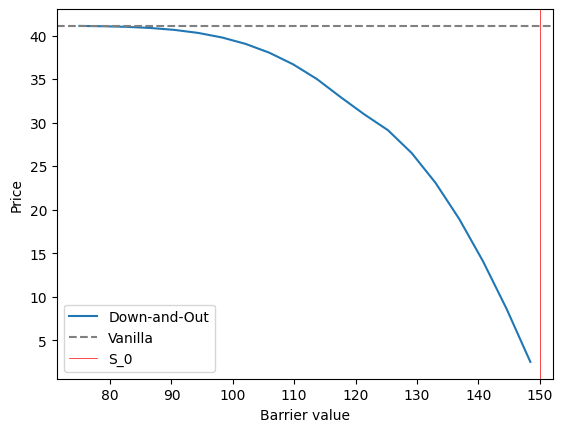

In [45]:
L_values=np.linspace(0.5*x, 0.99*x, 20)
do_results=[]
for L in L_values:
    do_results.append(DownAndOutCall(T, r, x, K1, L, sigma))

plt.plot(L_values, do_results, label='Down-and-Out')
plt.axhline(vanilla1, linestyle='--', color='grey', label='Vanilla')
plt.axvline(x, color='red', linewidth=0.5, label='S_0')
plt.xlabel('Barrier value')
plt.ylabel('Price')
plt.legend()

Convergence rate (L -> 0): 16.356570783852785


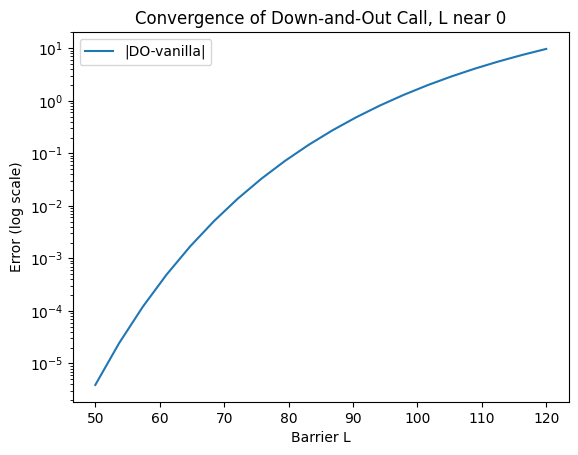

In [46]:
Ls_small =np.linspace(50, 0.8*x, 20)

DO_small = [DownAndOutCall(T, r, x, K1, L, sigma) for L in Ls_small]
V = EurCall(T,r,x,K1,sigma)

err_to_vanilla = np.abs(np.array(DO_small) - V)

plt.plot(Ls_small,err_to_vanilla, label='|DO-vanilla|')
plt.yscale("log")
plt.xlabel("Barrier L")

plt.ylabel("Error (log scale)")
plt.legend()
plt.title("Convergence of Down-and-Out Call, L near 0")

#QUANTIFY RATE OF CONVERGENCE

x1 = np.array(Ls_small)   # small L values
e1 = np.abs(DO_small - V)

log_x1 = np.log(x1)
log_e1 = np.log(e1)

alpha1 = np.polyfit(log_x1, log_e1, 1)[0]
print("Convergence rate (L -> 0):", alpha1)

Convergence rate (L -> S): 0.9073869853723155


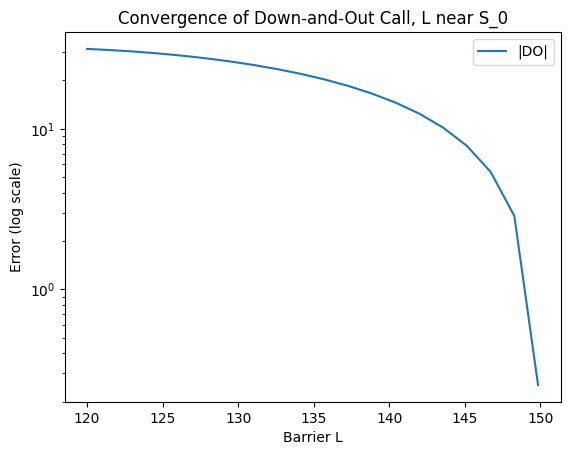

In [47]:
Ls_large =np.linspace(0.8*x, 0.999*x, 20)

DO_large = [DownAndOutCall(T, r, x, K1, L, sigma) for L in Ls_large]
V = EurCall(T,r,x,K1,sigma)

err_to_zero = np.abs(np.array(DO_large))

plt.plot(Ls_large, err_to_zero, label='|DO|')
plt.yscale("log")
plt.xlabel("Barrier L")

plt.ylabel("Error (log scale)")
plt.legend()
plt.title("Convergence of Down-and-Out Call, L near S_0")

x2 = x - np.array(Ls_large)

e2 = np.abs(DO_large)

log_x2 = np.log(x2)

log_e2 = np.log(e2)

alpha2 = np.polyfit(log_x2, log_e2, 1)[0]

print("Convergence rate (L -> S):", alpha2)

Convergence analysis of the down-and-out call

We verify the limiting behaviour of the down-and-out call as the barrier level L varies.

As $L \to 0$, the option price converges to the vanilla call, since the barrier becomes inactive. Numerically, the pricing error $|C^{DO}(L) - C^{vanilla}|$ decreases very rapidly. A log–log regression yields an apparently large slope (~16), but this is not a true asymptotic rate: it is caused by floating-point precision effects when the two prices become numerically indistinguishable.

As $L \to S^{-}$, the option price converges to zero, reflecting the near-certainty of immediate knock-out. In this regime, the error scales approximately linearly with $S - L$, with an estimated convergence rate close to 1, consistent with first-passage intuition.

Overall, the numerical results confirm the correct limiting behaviour of the model in both regimes, with a meaningful linear scaling near the barrier and numerical saturation effects far from it.

3. Compute Delta using finite differences:  
$$\Delta \approx \frac{V(S_0 + \epsilon)-V(S_0 - \epsilon)}{2 \epsilon}$$
• Compare the Delta of the barrier option with that of the vanilla option.  
• Repeat for different values of 𝑆0, especially near the barrier.  
• Comment on any discontinuities or instabilities. 

The Delta of the barrier option was computed using a central finite difference approximation:$$\Delta \approx \frac{V(S_0 + \epsilon) - V(S_0 - \epsilon)}{2\epsilon}$$where $V(S)$ represents the option price at spot $S$, and $\epsilon$ is a small price perturbation. The resulting comparison highlights a stark contrast in the risk profiles of vanilla and barrier instruments. While the vanilla call Delta is a smooth, monotonic function bounded between $0$ and $1$, the Down-and-Out call Delta exhibits a significant discontinuity and "overshoot" near the barrier $L$.

In [48]:
def delta_fd(S, K, B, T, r, sigma, q=0, e=1e-4):
    
    V_plus = DownAndOutCall(T, r, S+e, K, B, sigma)
    V_minus = DownAndOutCall(T, r, S-e, K, B, sigma)
    
    delta = (V_plus - V_minus) / (2 * e)
    
    return  delta

def delta_vanilla_bs(S, K, T, r, sigma, q=0):

    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

    return np.exp(-q*T) * norm.cdf(d1)

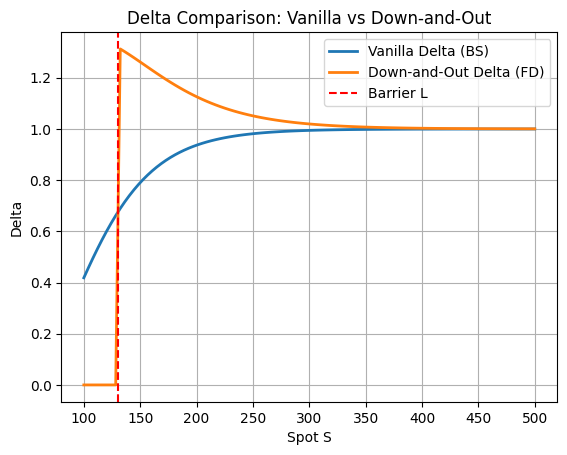

In [49]:
S_grid = np.linspace(100, 500, 100)

delta_DO = []

delta_Vanilla = []

for S in S_grid:

    # barrier delta (central FD)

    d_do = delta_fd(S, K1, B, T, r, sigma)

    # vanilla delta (closed form)

    d_van = delta_vanilla_bs(S, K1, T, r, sigma)

    delta_DO.append(d_do)

    delta_Vanilla.append(d_van)

delta_DO = np.array(delta_DO)

delta_Vanilla = np.array(delta_Vanilla)

# -----------------------------
# PLOT COMPARISON
# -----------------------------

plt.figure()

plt.plot(S_grid, delta_Vanilla, label="Vanilla Delta (BS)", linewidth=2)

plt.plot(S_grid, delta_DO, label="Down-and-Out Delta (FD)", linewidth=2)

plt.axvline(B, linestyle="--", color="red", label="Barrier L")

plt.xlabel("Spot S")

plt.ylabel("Delta")

plt.title("Delta Comparison: Vanilla vs Down-and-Out")

plt.legend()

plt.grid()

plt.show()

As shown in the figure, the Delta of the Down-and-Out call is zero for $S < L$, reflecting the knocked-out state. However, as the spot price approaches the barrier from above, the Delta spikes sharply, exceeding $1.0$. This instability, often referred to as "barrier risk," occurs because the option's value drops abruptly to zero the moment the barrier is touched. Near $L$, the option behaves like a leveraged position with extreme sensitivity to small price movements; a slight decrease in $S$ could result in the total loss of the premium. This creates a challenging hedging environment, as a delta-neutral hedge would require a massive short position in the underlying asset that must be liquidated instantly if the barrier is breached. Furthermore, numerical instabilities can arise if $\epsilon$ is too large relative to the distance to the barrier ($S - L$), necessitating high-precision pricing and adaptive step sizes for effective risk management.

4. Compute the option price for values of 𝑆0 increasingly close to the barrier 𝐿.  
• Plot the price as a function of 𝑆0.  
• Analyze the sensitivity of the price near the barrier.  
• Comment on the implications for hedging. 

To analyze the behavior of the option as $S$ approaches $L$, we need to generate a range of spot prices that "zoom in" on the barrier.The following code calculates the prices for both $K < L$ and $K > L$ scenarios, plots them, and computes the numerical Delta specifically in that sensitive zone.

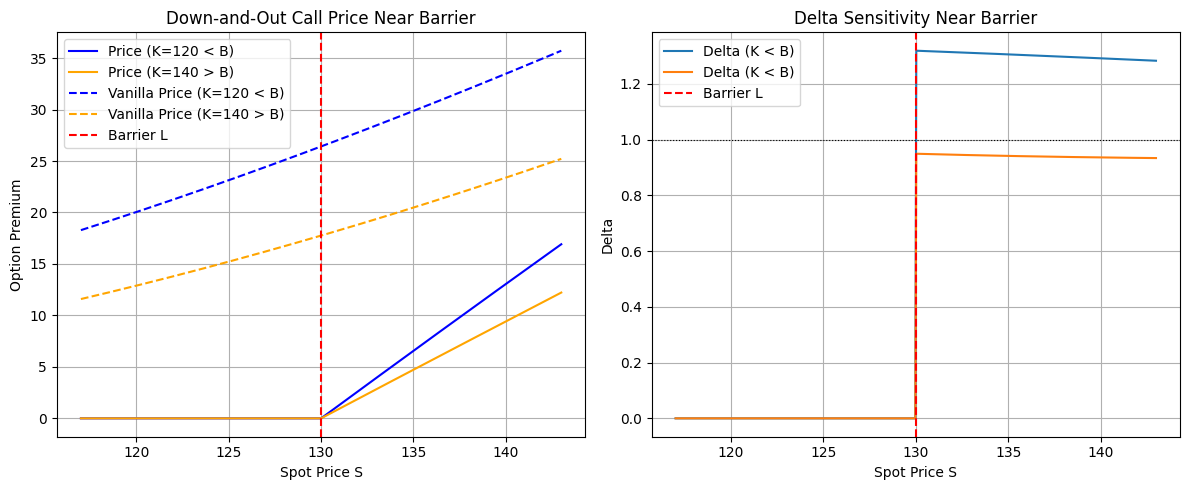

In [50]:
# 1. Setup range for S approaching L from above
# We start from L + epsilon and move away to see the convergence
epsilon = 1e-4
s_near = np.linspace(B - 0.1*B, B + 0.1*B, 500)

# 2. Compute prices for both strike cases
# K1 < B (120 < 130)
prices_k1 = [DownAndOutCall(T, r, s, K1, B, sigma) for s in s_near]
# K2 > B (140 > 130)
prices_k2 = [DownAndOutCall(T, r, s, K2, B, sigma) for s in s_near]

prices_v1=[EurCall(T, r, s, K1, sigma) for s in s_near]
prices_v2=[EurCall(T, r, s, K2, sigma) for s in s_near]

# 3. Numerical Delta near the barrier using Finite Differences
deltas_k1 = [delta_fd(s, K1, B, T, r, sigma) for s in s_near]
deltas_k2 = [delta_fd(s, K2, B, T, r, sigma) for s in s_near]

# 4. Plotting
plt.figure(figsize=(12, 5))

# Plot Price
plt.subplot(1, 2, 1)
plt.plot(s_near, prices_k1, color='blue', label=f'Price (K={K1} < B)')
plt.plot(s_near, prices_k2, color='orange', label=f'Price (K={K2} > B)')
plt.plot(s_near, prices_v1, color='blue',linestyle='--', label=f'Vanilla Price (K={K1} < B)')
plt.plot(s_near, prices_v2, color='orange',linestyle='--', label=f'Vanilla Price (K={K2} > B)')
plt.axvline(B, color='r', linestyle='--', label='Barrier L')
plt.title('Down-and-Out Call Price Near Barrier')
plt.xlabel('Spot Price S')
plt.ylabel('Option Premium')
plt.grid(True)
plt.legend()

# Plot Delta Sensitivity
plt.subplot(1, 2, 2)
plt.plot(s_near, deltas_k1, label='Delta (K < B)')
plt.plot(s_near, deltas_k2, label='Delta (K < B)')
plt.axvline(B, color='r', linestyle='--', label='Barrier L')
plt.axhline(1.0, color='black', lw=0.8, linestyle=':')
plt.title('Delta Sensitivity Near Barrier')
plt.xlabel('Spot Price S')
plt.ylabel('Delta')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

The comparison between the solid lines (Down-and-Out) and dashed lines (Vanilla) clearly illustrates that the barrier option is strictly cheaper, with the price difference widening significantly as the spot price approaches the barrier $L=130$. While the vanilla call remains valuable even below $130$, the barrier option collapses to zero, creating a sharp "elbow" in the price curve. This geometric sharpness translates directly into the Delta Spike seen in your second plot. For $K=120$, the Delta doesn't just approach $1.0$; it jumps to approximately $1.3$, a phenomenon known as "Delta overshooting." This occurs because the option must shed its entire remaining value instantaneously upon hitting the barrier, requiring a slope steeper than the underlying asset itself.

Financial and Hedging Implications
From a hedging perspective, these results signify extreme Gamma risk near the barrier. A trader long this option would need to hold more than one unit of the underlying asset to remain Delta-neutral near $130$. However, the moment the barrier is touched, that entire hedge must be liquidated, often into a falling market, leading to significant slippage. These plots effectively capture the "cliff-edge" nature of barrier instruments, where the benefits of a lower entry premium are offset by the discontinuous and unstable risk parameters as the underlying nears the knockout level.

## Monte Carlo simulation

5. Implement a Monte Carlo simulation for the same down-and-out call.  
• Compare the Monte Carlo price with the closed-form price.  
• Analyze the effect of the number of paths and time discretization.  
• Comment on the differences (discretization bias). 

The value of the option should be $$V_t = e^{−r(T−t)}\mathbb{E}[(S_T − K)^+\mathbf{1}_{S_u \ge B,\forall u \in (t,T)}|\mathcal{F}_t]$$ where $\mathbb{E}$ is in the risk neutral measure.

Using the SDE
$$dS_t = rS_tdt + \sigma S_tdW_t$$
 this program computes one trajectory of $S_t$ for $t < T$; it returns a list of values $S_0, S_{\Delta t}, S_{2 \Delta t}, ..., S_T$ for $\Delta T = \frac{T}{N}$ where $N$ is the number of points.

In [51]:
def SGenerate(T,N,r,sigma,x,t=0,):
    import numpy as np
    step = (T-t)/N
    S = x
    S_path = [S]
    for i in range(N):
        dw = np.random.normal(0, np.sqrt(step))
        dS = r*S*step+sigma*S*dw
        S += dS
        S_path.append(S) 
    return S_path

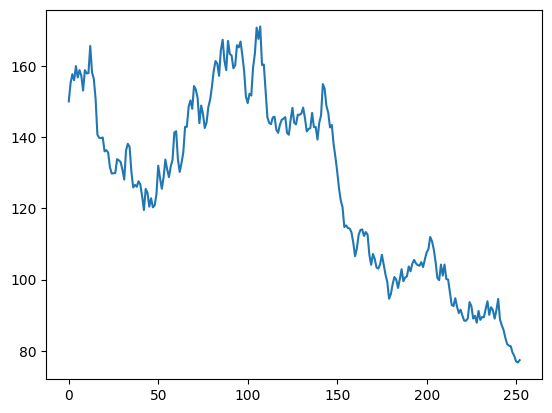

In [52]:
plt.plot(SGenerate(T, 252, r, sigma, x))

In [53]:
def Payoff(T,N,r,sigma,x,B,K,t=0):
    S_path = SGenerate(T,N,r,sigma,x,t)
    if min(S_path) > B:
        return max(S_path[-1]-K,0),S_path
    else:
        return 0,S_path
    
# example
Payoff(T, 252, r, sigma, x, B, K1)[0]

0

In [54]:
def MC(Np,T,N,r,sigma,x,B,K,t=0):
    import numpy as np
    payoffs = []
    for j in range(Np):
        payoff = Payoff(T,N,r,sigma,x,B,K,t)[0]
        payoffs.append(payoff)
    discounted_payoffs = np.array(payoffs) * np.exp(-r * (T - t))
    price=np.mean(discounted_payoffs)
    variance = np.var(discounted_payoffs)
    # Standard Error (SE) = Std_Deviation / sqrt(Number of Paths)
    standard_error = np.std(discounted_payoffs) / np.sqrt(Np)
    return payoffs, price, variance, standard_error

In [55]:
Np=1000
N=252

MCpayoffs, MCprice, MCvariance, MCstandard_error= MC(Np, T, N, r, sigma, x, B, K1)

print("MC results: ", MCprice, "+-", MCstandard_error, "\nClosed-form price: ", do_call1)

MC results:  24.463465438165453 +- 1.6574880826014589 
Closed-form price:  25.822021075388164


In [56]:
Np_vals=np.logspace(1, 6)

np_price=[]
np_err=[]

for npv in Np_vals:
    MCpayoffs, MCprice, MCvariance, MCstandard_error= MC(int(npv), T, N, r, sigma, x, B, K1)
    np_price.append(MCprice)
    np_err.append(MCstandard_error)



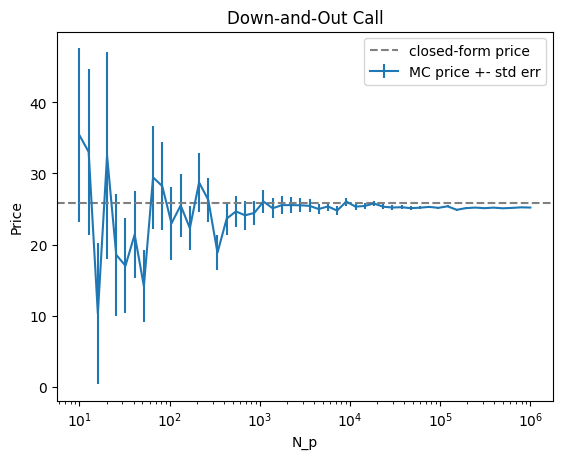

In [57]:
plt.errorbar(Np_vals, np_price, np_err, label=r'MC price +- std err')
plt.axhline(do_call1, linestyle='--', color='grey', label='closed-form price')
plt.xscale('log')
plt.xlabel(r'N_p')
plt.ylabel('Price')
plt.title('Down-and-Out Call')
plt.legend()
plt.show()

At low values of $N_p$ ($< 10^2$), the simulation exhibits significant volatility, with the estimated price oscillating wildly around the theoretical value. This high variance is characteristic of the Monte Carlo method, where early samples may be dominated by "outlier" paths—either those that result in high payoffs or those that are prematurely knocked out. As $N_p$ increases, the estimator stabilizes, and the magnitude of the error bars shrinks at the theoretical rate of $\mathcal{O}(1/\sqrt{N_p})$. By $N_p = 10^4$, the statistical noise has largely dissipated, and the MC price remains consistently close to the closed-form benchmark.

In [58]:
N_vals=np.logspace(1, 5)

n_price=[]
n_err=[]

for nv in N_vals:
    MCpayoffs, MCprice, MCvariance, MCstandard_error= MC(Np, T, int(nv), r, sigma, x, B, K1)
    n_price.append(MCprice)
    n_err.append(MCstandard_error)


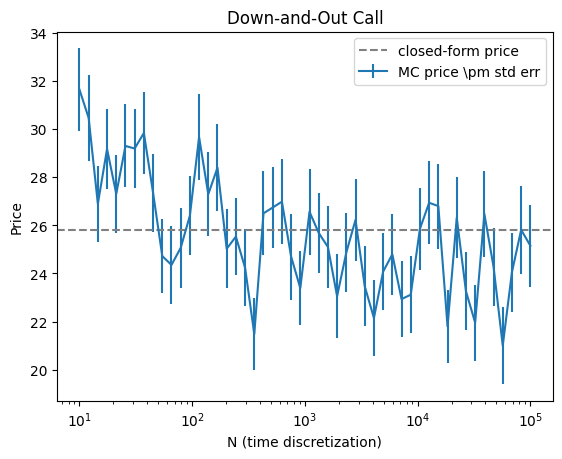

In [59]:
plt.errorbar(N_vals, n_price, n_err, label=r'MC price \pm std err')
plt.axhline(do_call1, linestyle='--', color='grey', label='closed-form price')
plt.xscale('log')
plt.xlabel(r'N (time discretization)')
plt.ylabel('Price')
plt.title('Down-and-Out Call')
plt.legend()
plt.show()

The figure demonstrates the discretization bias inherent in path-dependent simulations. While increasing the number of paths ($N_p$) reduces statistical noise, increasing the number of steps ($N$) is required to eliminate systematic pricing errors.

At low values of $N$, the Monte Carlo price significantly overestimates the closed-form price. This is due to the "monitoring gap": in a discrete simulation, the barrier is only checked at specific intervals. A path may breach the barrier between steps and recover, remaining "alive" in the simulation while it would be "knocked out" in the continuous-time analytical model. As $N$ increases, the probability of missing these intra-step breaches decreases.

As $N$ approaches $10^5$, the Monte Carlo estimator converges toward the analytical benchmark (dashed line). This convergence confirms that the "discrete" barrier is becoming a closer approximation of the "continuous" barrier. However, achieving this accuracy is computationally expensive, as the simulation time scales linearly with $N$.

## Implied volatility

6. Given a market price for the barrier option, estimate the implied volatility.  
• Implement a numerical method (bisection or Newton).  
• Verify convergence of the algorithm.  
• Compare with the implied volatility of the vanilla option and comment the results.

In [60]:
def find_implied_vol(target_price, T, r, s, K, L, pricer='DO'):
    # 1. Define the objective function: f(sigma) = Price(sigma) - MarketPrice
    def f(sigma):
        if pricer=='DO':
            return DownAndOutCall(T, r, s, K, L, sigma) - target_price
        elif pricer=='Vanilla':
            return EurCall(T,r,s, K, sigma) - target_price
        else: print("Invalid value or pricer. Pricer must be 'DO' or 'Vanilla'")

    # 2. Set search bounds for volatility (e.g., between 1% and 200%)
    low = 0.001
    high = 2.0
    tol = 1e-8
    iterations = []
    
    # Bisection Loop
    for i in range(500):
        mid = (low + high) / 2
        val = f(mid)
        iterations.append(mid) # Store for convergence check
        
        if abs(val) < tol:
            break
            
        if f(low) * val < 0:
            high = mid
        else:
            low = mid
            
    return mid, iterations


In [61]:
true_sigma = 0.1
mkt_price = DownAndOutCall(T, r, x, K1, B, true_sigma) # Use our model to create a "Market Price"

do_iv, do_conv_steps = find_implied_vol(mkt_price, T, r, x, K1, B, 'DO')
print(f"Recovered Implied Vol of DO: {do_iv:.6f} in {len(do_conv_steps)} steps")

v_iv, v_conv_steps = find_implied_vol(mkt_price, T, r, x, K1, B, 'Vanilla')
print(f"Recovered Implied Vol of Vanilla: {v_iv:.6f} in {len(v_conv_steps)} steps")

test_price_do = DownAndOutCall(T, r, x, K1, B, 0.1)
test_price_vanilla = EurCall(T, r, x, K1, 0.358372)

print(f"At sigma=0.1, DO Price: {test_price_do}")
print(f"At sigma=0.358372, Vanilla Price: {test_price_vanilla}")

Recovered Implied Vol of DO: 0.100000 in 32 steps
Recovered Implied Vol of Vanilla: 0.358372 in 31 steps
At sigma=0.1, DO Price: 39.36600901736014
At sigma=0.358372, Vanilla Price: 39.366002102172075


In [65]:
true_sigma = 0.3
mkt_price = DownAndOutCall(T, r, 135, K1, B, true_sigma) # Use our model to create a "Market Price"
x=135

do_iv, do_conv_steps = find_implied_vol(mkt_price, T, r, x, K1, B, 'DO')
print(f"Recovered Implied Vol of DO: {do_iv:.6f} in {len(do_conv_steps)} steps")

v_iv, v_conv_steps = find_implied_vol(mkt_price, T, r, x, K1, B, 'Vanilla')
print(f"Recovered Implied Vol of Vanilla: {v_iv:.6f} in {len(v_conv_steps)} steps")

test_price_do = DownAndOutCall(T, r, 135, K1, B, 0.3)
test_price_vanilla = EurCall(T, r, 135, K1, 0.1)

print(f"At sigma=0.3, DO Price: {test_price_do}")
print(f"At sigma=0.1, Vanilla Price: {test_price_vanilla}")

Recovered Implied Vol of DO: 0.300000 in 30 steps
Recovered Implied Vol of Vanilla: 2.000000 in 500 steps
At sigma=0.3, DO Price: 7.228215683790104
At sigma=0.1, Vanilla Price: 17.860826943962863
